In [35]:
import pandas as pd
import io

path = "/Users/ds39/Documents/Sunny/MAVE/RD_projects/concentration/Updated_CellCounts_masterfiles.csv"

In [36]:
df=pd.read_csv(path)

In [37]:
df

,Targeton Name,Gene,Screen ID,Hdr Vector Lot,HDR_nanodrop (ng/ul),HDR_A260/A280,HDR_A260/A230,Qubit(ng/ul),HDR_actual_DNA,gRNA Vector Lot,...,D4R2 Mapped Reads,D4R3 Mapped Reads,Average_mapped_reads,Comment,Average_TransfectionEfficency_GFP,Average_Cell_Count,Average_Total_Cells,%_Surviving_Cells,Estimated_Edited_Cells,%_Successful_Edited_Cells
0,AXFG,SMC1A,AXFG_1_scr173,AXFG_hdr500,4360.0,1.948,2.563,246.0,0.846330,AXFG_gRNAvec581,...,28.0,26.9,27.300000,NaN,47.25,4371666.667,34973333.33,174.866667,9547720.00,47.738600
1,BBAI,CTCF,BBAI_1_scr124,BBAI_hdr412,929.8,1.912,2.342,615.0,9.921488,BBAI_gRNAvec307,...,52.9,54.8,51.500000,NaN,57.50,2960000.000,23680000.00,118.400000,12195200.00,60.976000
2,BCWL,DDX23,BCWL_1_scr157,BCWL_hdr483,827.6,2.003,2.755,252.0,4.567424,BCWL_gRNAvec022,...,37.2,34.7,31.933333,NaN,NaN,5065000.000,40520000.00,202.600000,12939386.67,64.696933
3,BPAV,POLD1,BPAV_1_scr228,BPAV_hdr610,1125.6,1.997,2.650,264.0,3.518124,BPAV_gRNAvec034,...,32.1,30.6,30.933333,NaN,56.00,NaN,NaN,NaN,NaN,NaN
4,BUKA,CTCF,BUKA_4_scr148,BUKA_hdr484,2508.1,1.910,2.434,650.0,3.887405,BUKA_gRNAvec635,...,53.9,53.7,53.700000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,XSQZ,CNOT3,XSQZ_2_scr231,XSQZ_hdr489,1258.4,1.998,2.645,178.0,2.121742,XSQZ_gRNAvec678,...,42.4,41.7,42.333333,NaN,57.10,NaN,NaN,NaN,NaN,NaN
61,YBNX,CREBBP,YBNX_1_scr164,YBNX_hdr490,4977.2,1.930,2.467,542.0,1.633449,YBNX_gRNAvec653,...,46.2,44.8,45.666667,NaN,54.45,5341666.667,42733333.33,213.666667,19514888.89,97.574444
62,YJWX,MAP3K15,YJWX_1_scr224,YJWX_hdr628,837.9,1.972,2.664,238.0,4.260652,YJWX_gRNAvec109,...,19.3,17.9,18.966667,NaN,67.20,NaN,NaN,NaN,NaN,NaN
63,YMXP,CHD3,YMXP_1_scr134,YMXP_hdr426,2634.6,1.920,2.310,680.0,3.871555,YMXP_gRNAvec110,...,32.9,33.6,33.266667,NaN,64.35,5330000.000,42640000.00,213.200000,14184906.67,70.924533


In [39]:
df.columns

Index(['Targeton Name', 'Gene', 'Screen ID', 'Hdr Vector Lot',
       'HDR_nanodrop (ng/ul)', 'HDR_A260/A280', 'HDR_A260/A230',
       'Qubit(ng/ul)', 'HDR_actual_DNA', 'gRNA Vector Lot',
       'gRNA_nanodrop (ng/ul)', 'gRNA_A260/A280', 'gRNA_A260/A230',
       'gRNA_Qubit (ng/ul)', 'gRNA_actual_DNA', 'Per_Million_TotalDNA',
       'D4R1 Mapped Reads', 'D4R2 Mapped Reads', 'D4R3 Mapped Reads',
       'Average_mapped_reads', 'Comment', 'Average_TransfectionEfficency_GFP',
       'Average_Cell_Count', 'Average_Total_Cells', '%_Surviving_Cells',
       'Estimated_Edited_Cells', '%_Successful_Edited_Cells'],
      dtype='object')

In [40]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import shap

# ── 1. LOAD YOUR REAL DATASET ──


cols_to_drop = ['Targeton Name', 'Gene', 'Screen ID', 'Hdr Vector Lot', 'Comment','gRNA Vector Lot','D4R1 Mapped Reads', 'D4R2 Mapped Reads', 'D4R3 Mapped Reads' ]  # <-- Replace with actual names
df = df.drop(columns=cols_to_drop)
df = df.fillna(0)


print("Original columns in df:")
print(df.columns.tolist())

# ── 2. DROP ANY ROWS WITH MISSING VALUES ──
df = df.dropna()
print("\nAfter dropna, columns remain:")
print(df.columns.tolist())

# ── 3. DEFINE FEATURE COLUMNS AND TARGET COLUMN ──

target_col = 'Average_mapped_reads'
feature_names = [col for col in df.columns if col != target_col]

print(f"\nUsing {len(feature_names)} feature columns:")
print(feature_names)

X = df[feature_names].values
y = (df[target_col] > 40).astype(int)  # 1 if >40, else 0

print(f"\nUsing {len(feature_names)} feature columns:")
print(feature_names)

X = df[feature_names]
y = df[target_col]

# ── 4. SPLIT INTO TRAIN/VALID ──
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=0)

# ── 5. TRAIN THE FULL RANDOM FOREST ──
model_all = RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1)
model_all.fit(X_train, y_train)

# ── 6. CALCULATE SHAP VALUES ──
explainer = shap.TreeExplainer(model_all)
shap_values = explainer.shap_values(X_valid)

# ── 7. MEAN SHAP IMPORTANCE ──
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
feature_importance = list(zip(feature_names, mean_abs_shap))
feature_importance.sort(key=lambda x: x[1], reverse=True)

print("\nTop 10 features by mean(|SHAP|):")
for feat, score in feature_importance[:10]:
    print(f"  {feat:<20} → {score:.4f}")

# ── 8. SELECT TOP FEATURES ──
N = 12
top_features = [f for f, _ in feature_importance[:N]]
print(f"\nTop {N} features: {top_features}")

# ── 9. RETRAIN WITH TOP FEATURES ──
X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_valid_df = pd.DataFrame(X_valid, columns=feature_names)

X_train_red = X_train_df[top_features]
X_valid_red = X_valid_df[top_features]

model_red = RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1)
model_red.fit(X_train_red, y_train)

# ── 10. EVALUATE ──
y_pred_all = model_all.predict(X_valid)
y_pred_red = model_red.predict(X_valid_red)

r2_all = r2_score(y_valid, y_pred_all)
rmse_all = np.sqrt(mean_squared_error(y_valid, y_pred_all))

r2_red = r2_score(y_valid, y_pred_red)
rmse_red = np.sqrt(mean_squared_error(y_valid, y_pred_red))

print("\nModel performance:")
print(f"  • Full model    → R² = {r2_all:.3f}, RMSE = {rmse_all:.3f}")
print(f"  • Reduced model → R² = {r2_red:.3f}, RMSE = {rmse_red:.3f}")

# ── 11. EXPORT SHAP FEATURE IMPORTANCE TO CSV ──
top_n = 12  # You can change this if needed
df_all_shap = pd.DataFrame(feature_importance, columns=["Feature", "Mean(|SHAP|)"])
df_all_shap.to_csv("all_shap_features.csv", index=False)
print("Saved all SHAP features to 'all_shap_features.csv'")



Original columns in df:
['HDR_nanodrop (ng/ul)', 'HDR_A260/A280', 'HDR_A260/A230', 'Qubit(ng/ul)', 'HDR_actual_DNA', 'gRNA_nanodrop (ng/ul)', 'gRNA_A260/A280', 'gRNA_A260/A230', 'gRNA_Qubit (ng/ul)', 'gRNA_actual_DNA', 'Per_Million_TotalDNA', 'Average_mapped_reads', 'Average_TransfectionEfficency_GFP', 'Average_Cell_Count', 'Average_Total_Cells', '%_Surviving_Cells', 'Estimated_Edited_Cells', '%_Successful_Edited_Cells']

After dropna, columns remain:
['HDR_nanodrop (ng/ul)', 'HDR_A260/A280', 'HDR_A260/A230', 'Qubit(ng/ul)', 'HDR_actual_DNA', 'gRNA_nanodrop (ng/ul)', 'gRNA_A260/A280', 'gRNA_A260/A230', 'gRNA_Qubit (ng/ul)', 'gRNA_actual_DNA', 'Per_Million_TotalDNA', 'Average_mapped_reads', 'Average_TransfectionEfficency_GFP', 'Average_Cell_Count', 'Average_Total_Cells', '%_Surviving_Cells', 'Estimated_Edited_Cells', '%_Successful_Edited_Cells']

Using 17 feature columns:
['HDR_nanodrop (ng/ul)', 'HDR_A260/A280', 'HDR_A260/A230', 'Qubit(ng/ul)', 'HDR_actual_DNA', 'gRNA_nanodrop (ng/ul)'

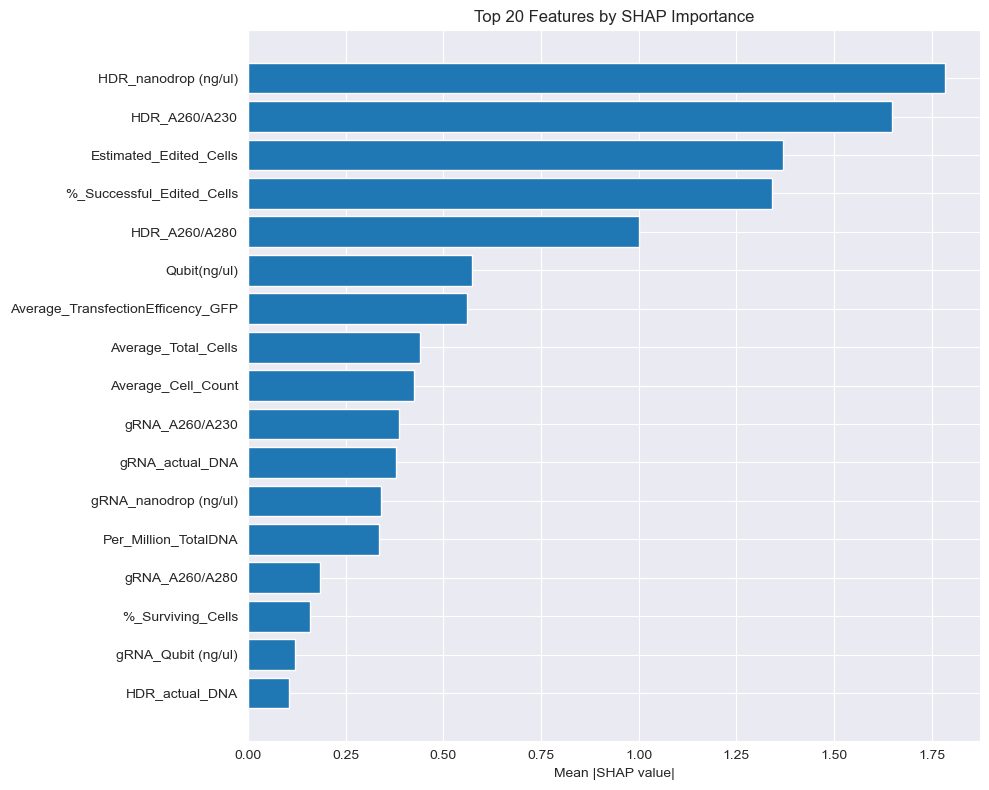


✅ SHAP summary plot saved as 'shap_summary_plot.png'
✅ SHAP feature importance table saved as 'shap_feature_importance.csv'


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import os

# ── 1. Define Feature Names ──
feature_names = X.columns.tolist()

# ── 2. Train/Test Split ──
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# ── 3. Train Random Forest ──
model = RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1)
model.fit(X_train, y_train)

# ── 4. Compute SHAP Values ──
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_valid)

# ── 5. Mean(|SHAP|) Importance ──
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
feat_importance = sorted(
    zip(feature_names, mean_abs_shap),
    key=lambda x: x[1],
    reverse=True
)

# ── 6. Convert to DataFrame and Export ──
shap_df = pd.DataFrame(feat_importance, columns=["Feature", "Mean(|SHAP|)"])
shap_df.to_csv("shap_feature_importance.csv", index=False)

# ── 7. Bar Plot for Top N Features ──
top_n = 20
top_feats = feat_importance[:top_n]
names = [f[0] for f in top_feats][::-1]
scores = [f[1] for f in top_feats][::-1]

plt.figure(figsize=(10, 8))
plt.barh(names, scores)
plt.xlabel('Mean |SHAP value|')
plt.title(f'Top {top_n} Features by SHAP Importance')
plt.tight_layout()
plt.savefig("shap_top_features_barplot.png", dpi=300)
plt.show()

# ── 8. SHAP Summary Plot ──
shap.summary_plot(shap_values, X_valid, feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig("shap_summary_plot.png", dpi=300)
plt.close()

print("\n✅ SHAP summary plot saved as 'shap_summary_plot.png'")
print("✅ SHAP feature importance table saved as 'shap_feature_importance.csv'")


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix

# ── 1. DEFINE FEATURES + BINARIZED TARGET ──
selected_features = [
    'HDR_nanodrop (ng/ul)', 'HDR_A260/A230', 'Estimated_Edited_Cells', '%_Successful_Edited_Cells',
    'HDR_A260/A280', 'Qubit(ng/ul)', 'Average_TransfectionEfficency_GFP', 'Average_Total_Cells',
    'Average_Cell_Count', 'gRNA_A260/A230', 'gRNA_actual_DNA', 'gRNA_nanodrop (ng/ul)'
]
target_col = 'Average_mapped_reads'

# Binary label: High = 1 if >40, else Low = 0
X = df[selected_features].copy()
y = (df[target_col] > 40).astype(int)

# Filter classes with <2 samples
class_counts = Counter(y)
valid_classes = [cls for cls, count in class_counts.items() if count >= 2]
mask = y.isin(valid_classes)
X = X[mask]
y = y[mask]

# ── 2. SPLIT INTO TRAIN/TEST ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=0, stratify=y
)

# ── 3. MODEL ZOO ──
classifiers = {
    'KNN (k=5)'           : KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)'           : SVC(kernel='rbf', probability=True, random_state=0),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=0),
    'Logistic Regression' : LogisticRegression(max_iter=500, random_state=0)
}

# ── 4. STRATIFIED 5-FOLD CV ──
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# ── 5. TRAIN & EVALUATE ──
results = []
for name, clf in classifiers.items():
    print(f"\n========== {name} ==========")

    # 5a. Cross-validation scores
    cv_scores = cross_val_score(clf, X_train, y_train, cv=skf, scoring='accuracy', n_jobs=-1)
    mean_cv = np.mean(cv_scores)
    std_cv = np.std(cv_scores)
    print("5-fold CV accuracies on TRAIN:")
    print("  ", np.round(cv_scores, 3))
    print(f"  Mean = {mean_cv:.3f}, Std = {std_cv:.3f}")

    # 5b. Fit and predict
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    # Classification report
    report_dict = classification_report(y_test, y_pred, target_names=['Low', 'High'], output_dict=True)
    for label in ['Low', 'High']:
        row = {
            'Model': name,
            'Class': label,
            'Precision': report_dict[label]['precision'],
            'Recall': report_dict[label]['recall'],
            'F1-score': report_dict[label]['f1-score'],
            'Support': report_dict[label]['support'],
            'CV_Mean': mean_cv,
            'CV_Std': std_cv
        }
        results.append(row)

    # 5c. Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    plt.figure(figsize=(4, 3))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Low', 'High'],
        yticklabels=['Low', 'High']
    )
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix ({name})')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{name.replace(" ", "_")}.png')
    plt.close()

# ── 6. EXPORT SUMMARY TABLE ──
summary_df = pd.DataFrame(results)
summary_df.to_csv('classification_summary.csv', index=False)
print("\n✓ Classification summary saved to 'classification_summary.csv'")





========== KNN (k=5) ==========
5-fold CV accuracies on TRAIN:
   [0.778 0.556 0.778 0.667 0.778]
  Mean = 0.711, Std = 0.089

========== SVM (RBF) ==========
5-fold CV accuracies on TRAIN:
   [0.667 0.667 0.667 0.556 0.556]
  Mean = 0.622, Std = 0.054

========== Random Forest ==========


/Users/ds39/miniforge3/envs/depimgs/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/ds39/miniforge3/envs/depimgs/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/ds39/miniforge3/envs/depimgs/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, le

5-fold CV accuracies on TRAIN:
   [0.778 0.667 0.667 0.667 0.667]
  Mean = 0.689, Std = 0.044

========== Gradient Boosting ==========
5-fold CV accuracies on TRAIN:
   [0.778 0.333 0.444 0.556 0.556]
  Mean = 0.533, Std = 0.147

========== Logistic Regression ==========
5-fold CV accuracies on TRAIN:
   [0.889 1.    0.889 0.778 0.667]
  Mean = 0.844, Std = 0.113

✓ Classification summary saved to 'classification_summary.csv'


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from ipywidgets import interact, FloatSlider
import ipywidgets as widgets

# ── 1. Select top features and target ──
top_features = [
    'HDR_nanodrop (ng/ul)', 'HDR_A260/A230', 'Estimated_Edited_Cells',
    '%_Successful_Edited_Cells', 'HDR_A260/A280', 'Qubit(ng/ul)',
    'Average_TransfectionEfficency_GFP', 'Average_Total_Cells',
    'Average_Cell_Count', 'gRNA_A260/A230', 'gRNA_actual_DNA',
    'gRNA_nanodrop (ng/ul)'
]
target_col = 'Average_mapped_reads'

# ── 2. Train model ──
X = df[top_features]
y = df[target_col]
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=0)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# ── 3. Base values for sliders ──
medians = X_train.median()
sliders = {}
for feat in top_features:
    min_val, max_val = X[feat].min(), X[feat].max()
    sliders[feat] = FloatSlider(
        value=medians[feat],
        min=min_val,
        max=max_val,
        step=(max_val - min_val) / 100,
        description=feat.split()[0][:10],
        continuous_update=False,
        layout=widgets.Layout(width='500px')
    )

# ── 4. Prediction function ──
def predict_interactively(**kwargs):
    input_df = pd.DataFrame([kwargs])
    pred = model.predict(input_df)[0]
    print(f"\n📈 Predicted Average Mapped Reads: {pred:.2f}")
    plt.figure(figsize=(5, 1))
    plt.barh(['Prediction'], [pred], color='skyblue')
    plt.xlim(0, max(y)*1.1)
    plt.xlabel('Mapped Reads')
    plt.tight_layout()
    plt.show()

# ── 5. Launch widget ──
interact(predict_interactively, **sliders)


interactive(children=(FloatSlider(value=1132.45, continuous_update=False, description='HDR_nanodr', layout=Lay…

<function __main__.predict_interactively(**kwargs)>

In [ ]:
#bash 
# direct to the directory 
# and then run this line of code; streamlit run concentration_interactive_model.py
